# Формирование датасета

## Импортируем библиотеки и создаем полезные функции

In [1]:
import pandas as pd
from dateutil.relativedelta import relativedelta

In [2]:
# Функция для замены значения на ключ словаря
def replace_with_dict_key(value, rep_dict):
    for key, values_list in rep_dict.items():
        if value in values_list:
            return key
    return None 

## Загружаем данные

In [3]:
raw_df = pd.read_csv(r'data/undefind_DSMED.csv', sep=';')
raw_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36297 entries, 0 to 36296
Data columns (total 13 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   ID истории болезни                    36297 non-null  object 
 1   Осн. диаг. при выписке МКБ10 (текст)  36297 non-null  object 
 2   Заголовок документа                   36297 non-null  object 
 3   Кол. лаб. показатель                  36236 non-null  object 
 4   Значение кол. показателя              36236 non-null  float64
 5   Ед. изм. кол. показателя              36236 non-null  object 
 6   Норма кол. показателя                 36236 non-null  object 
 7   Флаг нормы кол. показателя            36236 non-null  object 
 8   Кач. лаб. показатель                  7005 non-null   object 
 9   Значение кач. показателя              7005 non-null   object 
 10  Норма кач. показателя                 7005 non-null   object 
 11  Пол            

## Собственно, формирование датасета

In [4]:
# Посмотрим количество уникальных значений по колонкам
raw_df.nunique()

ID истории болезни                       243
Осн. диаг. при выписке МКБ10 (текст)      11
Заголовок документа                        1
Кол. лаб. показатель                     131
Значение кол. показателя                2608
Ед. изм. кол. показателя                  11
Норма кол. показателя                    123
Флаг нормы кол. показателя                 4
Кач. лаб. показатель                       7
Значение кач. показателя                 155
Норма кач. показателя                      5
Пол                                        2
Дата рождения пациента                   104
dtype: int64

Так как прогнозировать будем по показателям, то наши признаки в эталонном датасете - показатели лабораторных тестов

In [5]:
# Посмотрим состав Кол. лабораторных показателей
raw_df['Кол. лаб. показатель'].value_counts()

Кол. лаб. показатель
Гемоглобин (HGB)                                        1114
Средний объем эритроцита (MCV)                          1114
Гематокрит (HCT)                                        1114
Среднее содержание гемоглобина в эритроците (MCH)       1114
Средняя концентрация гемоглобина в эритроците (MCHC)    1114
                                                        ... 
Тромбокрит                                                 1
Эозинофилы, абсолютное количество                          1
Базофилы, абсолютное количество                            1
СОЭ по Панченкову                                          1
MXD#                                                       1
Name: count, Length: 131, dtype: int64

In [6]:
# Это словарь маппинга наименований лабораторных тестов

replacement_dict = {
    # Красная кровь
    'rbc': ['Эритроциты', 'Эритроциты (RBC)', 'Общее количество эритроцитов (RBC)', 'RBC'],
    'hgb': ['Гемоглобин', 'Гемоглобин (HGB)', 'HGB'],
    'hct': ['Гематокрит', 'Гематокрит (HCT)', 'HCT'],
    'mcv': ['Средний объем эритроцита', 'Средний объем эритроцита (MCV)', 'MCV'],
    'mch': ['Среднее содержание гемоглобина в эритроците', 'Среднее содержание гемоглобина в эритроците (MCH)', 'MCH'],
    'mchc': ['Средняя концентрация гемоглобина в эритроците', 'Средняя концентрация гемоглобина в эритроците (MCHC)', 'MCHC'],
    'rdw': ['Ширина распределения эритроцитов', 'Ширина распределения эритроцитов по объему (RDW)', 'RDW', 'Ширина распределения эритроцитов (RDW)'],
    'rdv_cv': ['Ширина распределения эритроцитов по объему, коэффициент вариации (RDW-CV)', 'Ширина распределения эритроцитов по объему, коэффициент вариации', 'RDW-CV '],
    'rdv_sd': ['Ширина распределения эритроцитов по объему, стандартное отклонение (RDW-SD)','Ширина распределения эритроцитов по объему, стандартное отклонение','Ширина распределения эритроцитов, стандартное отклонение (RDW-SD)', 'RDW-SD'],
    'ret_rel': ['RET%', 'Ретикулоциты %'],
    'ret_abs': ['Ретикулоциты кол-во'],    
    'cp': ['Цветовой показатель'],

    # Белая кровь
    'wbc': ['Лейкоциты', 'Лейкоциты (WBC)', 'Общее количество лейкоцитов (WBC)', 'WBC'],

    # Лейкоформула
    'ne_abs': ['Нейтрофилы, абсолютное количество', 'Нейтрофилы, абсолютное количество (NE#)', 'Абсолютное количество нейтрофилов (NE#)', 'Нейтрофилы #'],
    'ne_rel': ['Нейтрофилы, относительное количество', 'Нейтрофилы, относительное количество (NE%)', 'Относительное количество нейтрофилов (NE%)', 'Нейтрофилы %', 'NE%'],
    'ly_abs': ['Лимфоциты, абсолютное количество', 'Лимфоциты, абсолютное количество (LY#)', 'Абсолютное количество лимфоцитов (LY#)', 'Лимфоциты #'],
    'ly_rel': ['Лимфоциты, относительное количество', 'Лимфоциты, относительное количество (LY%)', 'Лимфоциты %', 'Относительное количество лимфоцитов (LY%)', 'Лимфоциты %', 'LY%', 'Лимфоциты'],
    'mo_abs': ['Моноциты, абсолютное количество', 'Моноциты, абсолютное количество (MO#)', 'Абсолютное количество моноцитов (MO#)', 'Моноциты #'],
    'mo_rel': ['Моноциты, относительное количество', 'Моноциты, относительное количество (MO%)', 'Моноциты %', 'Моноциты %', 'Относительное количество моноцитов (MO%)', 'MO%', 'Моноциты'],
    'eo_abs': ['Эозинофилы, абсолютное количество', 'Эозинофилы, абсолютное количество (EO#)', 'Абсолютное количество эозинофилов (EO#)', 'Эозинофилы # '],
    'eo_rel': ['Эозинофилы, относительное количество', 'Эозинофилы, относительное количество (EO%)', 'Эозинофилы %', 'Относительное количество эозинофилов (EO%)', 'EO%', 'Эозинофилы'],
    'ba_abs': ['Базофилы, абсолютное количество', 'Базофилы, абсолютное количество (BA#)', 'Абсолютное количество базофилов (BA#)', 'Базофилы #', 'Базофилы # '],
    'ba_rel': ['Базофилы, относительное количество', 'Базофилы, относительное количество (BA%)', 'Базофилы %', 'Относительное количество базофилов (BA%)', 'BA%', 'Базофилы'],
    'pal': ['Палочкоядерные'],
    'seg': ['Сегментоядерные'],
    'mxd_abs': ['Смешанная фракция, абсолютное количество (MXD#)', 'MXD# ', 'Смешанная фракция, абсолютное количество', 'MXD#'],
    'mxd_rel': ['Смешанная фракция, относительное количество (MXD%)', 'MXD%', 'Смешанная фракция, относительное количество', 'MXD'],
    'plasma': ['Плазматические клетки', 'Плазматич. клетки'], # в норме - 0-1%

    # Тромбоциты
    'plt': ['Тромбоциты', 'Тромбоциты (PLT)', 'PLT'],
    'pct': ['Тромбокрит', 'Тромбокрит (PCT)', 'PCT'],
    'mpv': ['Средний объем тромбоцита', 'Средний объём тромбоцитов', 'Средний объем тромбоцита (MPV)', 'MPV (Средний объём тромбоцитов)', 'MPV ', 'MPV'],
    'pdw': ['Ширина распределения тромбоцитов', 'Ширина распределения тромбоцитов по объему', 'Ширина распределения тромбоцитов (PDW)', 'PDW'],
    'plcr': ['P-LCR'],

    'soe': ['СОЭ Вест.', 'Скорость оседания эритроцитов (СОЭ) по Вестергрену', 'СОЭ по Панченкову', 'СОЭ Панч.'],

    'myelo': ['Миелоциты'], # в норме - 0 появление в периферической крови всегда указывает на патологию
    'yunye': ['Юные'], # в норме - 0 всегда требует обследования
    'blasty': ['Бласты'], # в норме - 0 опухолевые клетки, лейкоз
    'normobl_abs': ['Нормобласты', 'Нормобласты #'], # в норме - 0
    'normobl_rel': ['Нормобласты %'], # в норме - 0
    'prolym': ['Пролимфоциты'], # в норме - 0 "красный флаг", требующий исключения злокачественных заболеваний крови!
    'promyelo': ['Промиелоциты'], # в норме - 0  тревожный сигнал, требующий исключения лейкозов и других тяжелых заболеваний крови

    'noclass_abs': ['Неклассифицируемые кол-во'],
    'noclass_rel': ['Неклассифицируемые %'],
}

В составе тестов увидели много синонимов - нужно мапить на уникальные признаки. Сформировали словарь для маппинга

In [7]:
# начинаем первую очистку и создание нужных признаков
prep_df = raw_df.copy()
# Удаляем строки, где вообще нет показателей
# Конечно мы потеряем 61 строку с комментариями, но они либо о браке, либо непонятные
prep_df = prep_df.dropna(subset=['Кол. лаб. показатель'])
# Посчитаем возраст пациента в годах на 21.07.2025 - начало хакатона. Других дат нет
age_date = pd.to_datetime('2025-07-21')
prep_df['Дата рождения пациента'] = pd.to_datetime(prep_df['Дата рождения пациента'])
prep_df['age'] = prep_df['Дата рождения пациента'].apply(lambda x: relativedelta(age_date, x).years)
# Закодируем пол числом
prep_df['gender'] = prep_df['Пол'].apply(lambda x: 0 if 'ж' in x.lower() else 1)


In [8]:
# Формируем номер лаб исследования исходя из логики, что тесты в датасете расположены
# по хронологии сверху вниз и в одном ЛИ тесты не повторяются
lab_study = []
study_prefix = 0

def create_lab_study_num(lab_test):

    global lab_study
    global study_prefix
    res = 'result_'

    if lab_test in lab_study:
        lab_study.clear()
        study_prefix += 1
    else:
        lab_study.append(lab_test)
    return res + str(study_prefix)
prep_df['study_num'] = prep_df['Кол. лаб. показатель'].apply(lambda x: create_lab_study_num(x))
# формируем уникальный ID ЛИ из ID истории и номера ЛИ
prep_df['study_ID'] = prep_df['ID истории болезни'] + '_' + prep_df['study_num']

In [9]:
# добавляем унифицированные коды тестов из словаря синонимов
prep_df['lab_test'] = prep_df['Кол. лаб. показатель'].apply(lambda x: replace_with_dict_key(x, replacement_dict))

In [10]:
# Переводим г/дл в г/л в MCHC
prep_df.loc[prep_df['Ед. изм. кол. показателя'] == 'г/дл', 'Значение кол. показателя'] *= 10
prep_df.loc[prep_df['Ед. изм. кол. показателя'] == 'г/дл', 'Ед. изм. кол. показателя'] = 'г/л'

In [11]:
# посмотрим сколько тестов осталось после унификации
prep_df['lab_test'].value_counts()

lab_test
ly_rel         2213
hgb            1619
rbc            1619
mchc           1619
hct            1619
mch            1619
mcv            1619
plt            1617
wbc            1616
mo_rel         1549
eo_rel         1473
ly_abs         1470
ne_rel         1332
ne_abs         1319
ba_rel         1177
mpv             982
pct             925
cp              832
rdw             829
soe             794
mo_abs          784
seg             740
eo_abs          739
pal             736
ba_abs          732
rdv_sd          698
rdv_cv          696
pdw             657
mxd_abs         517
mxd_rel         517
myelo           316
yunye           304
noclass_rel     239
normobl_abs     192
blasty          143
noclass_abs     117
plcr             81
ret_rel          57
ret_abs          44
plasma           30
promyelo         21
normobl_rel      18
prolym           16
Name: count, dtype: int64

In [12]:
# Сформируем справочный фрейм с данными пациенов, чтоб домержить в основной датасет
pasp_df = prep_df[['study_ID', 'gender', 'age']].drop_duplicates().copy()
pat_pasp_df = prep_df[['ID истории болезни', 'gender', 'age']].drop_duplicates().copy()
pasp_df

,study_ID,gender,age
0,2e1d0b3f-488a-11ed-ab5a-0050568844e6_result_0,0,62
16,2e1d0b3f-488a-11ed-ab5a-0050568844e6_result_1,0,62
47,2e1d0b3f-488a-11ed-ab5a-0050568844e6_result_2,0,62
78,2e1d0b3f-488a-11ed-ab5a-0050568844e6_result_3,0,62
107,2e1d0b3f-488a-11ed-ab5a-0050568844e6_result_4,0,62
...,...,...,...
36176,6166e156-c1af-11ed-8602-005056880ecb_result_2637,1,43
36203,6166e156-c1af-11ed-8602-005056880ecb_result_2638,1,43
36227,6166e156-c1af-11ed-8602-005056880ecb_result_2639,1,43
36253,6166e156-c1af-11ed-8602-005056880ecb_result_2640,1,43


In [13]:
# Проверим референсные значения
ref_df = prep_df[['Пол', 'lab_test', 'Норма кол. показателя']].drop_duplicates()
# ref_df = prep_df[['Пол', 'Кол. лаб. показатель', 'Норма кол. показателя']].drop_duplicates()

ref_df[['lo_ref', 'hi_ref']] = ref_df['Норма кол. показателя'].str.split(':', n=1, expand=True)
ref_df.drop(columns=['Норма кол. показателя'], inplace=True)
ref_df['lo_ref'] = ref_df['lo_ref'].str.replace(',', '.')
ref_df['hi_ref'] = ref_df['hi_ref'].str.replace(',', '.')
ref_df.dropna(inplace=True)
ref_df[['lo_ref', 'hi_ref']] = ref_df[['lo_ref', 'hi_ref']].astype('float')
ref_df.drop_duplicates(inplace=True)
ref_df.sort_values(['Пол', 'lab_test'])
# ref_df.sort_values(['Пол', 'Кол. лаб. показатель'])


,Пол,lab_test,lo_ref,hi_ref
37,Ж,ba_abs,0.00,0.10
32,Ж,ba_rel,0.00,2.00
308,Ж,blasty,0.00,0.00
38,Ж,cp,0.80,1.05
1621,Ж,cp,0.85,1.15
...,...,...,...,...
484,М,soe,2.00,20.00
3590,М,soe,1.00,20.00
462,М,wbc,4.00,11.00
11344,М,wbc,4.00,8.80


Видим, что референсные значения разные для одних и тех же тестов, даже для одного пола. Похоже, на них не сможем ориентироваться, будем ориентироваться на флаги результата, т.к. они индивидуальны для каждого теста.

In [14]:
# Закодируем флаг результата числом: норма = 0, повышенный = 1, пониженный = -1
# пригодится, если захотим обучать не на абсолютах, а по флагам результата
prep_df['result'] = prep_df['Флаг нормы кол. показателя'].apply(lambda x: 0 if 'норм' in x.lower()
                                                                else (-1 if "пониж" in x.lower()
                                                                      else (1 if "повыш" in x.lower()
                                                                            else x)))

Займемся качественными показателями. У них нет числового результата и результатом будем считать флаг наличия или отсутствия признака.
Часть качественных признаков названа явно, а часть их описаны в комментариях, не все из которых полезны.

In [15]:
# Выделяем кач показатели, которые не в комментариях
mask = prep_df['Кач. лаб. показатель'].notna() & prep_df['Кач. лаб. показатель'].ne('Комментарий')
real_qual_df = prep_df[mask][['ID истории болезни', 'study_ID', 'Кач. лаб. показатель', 'Значение кач. показателя', 'Норма кач. показателя']].copy()
real_qual_df

,ID истории болезни,study_ID,Кач. лаб. показатель,Значение кач. показателя,Норма кач. показателя
930,76416b20-b70b-11ec-ab54-0050568844e6,76416b20-b70b-11ec-ab54-0050568844e6_result_38,Анизоцитоз,+,+-
931,76416b20-b70b-11ec-ab54-0050568844e6,76416b20-b70b-11ec-ab54-0050568844e6_result_39,Гипохромия,+,+-
932,76416b20-b70b-11ec-ab54-0050568844e6,76416b20-b70b-11ec-ab54-0050568844e6_result_39,Анизоцитоз,+,+-
933,76416b20-b70b-11ec-ab54-0050568844e6,76416b20-b70b-11ec-ab54-0050568844e6_result_40,Гипохромия,+,+-
934,76416b20-b70b-11ec-ab54-0050568844e6,76416b20-b70b-11ec-ab54-0050568844e6_result_40,Анизоцитоз,+,+-
...,...,...,...,...,...
36037,20f82885-b5cf-11ee-ab6f-0050568844e6,20f82885-b5cf-11ee-ab6f-0050568844e6_result_2627,Пойкилоцитоз,+++,+-
36039,20f82885-b5cf-11ee-ab6f-0050568844e6,20f82885-b5cf-11ee-ab6f-0050568844e6_result_2627,Анизоцитоз,+++,+-
36040,20f82885-b5cf-11ee-ab6f-0050568844e6,20f82885-b5cf-11ee-ab6f-0050568844e6_result_2628,Пойкилоцитоз,+++,+-
36042,20f82885-b5cf-11ee-ab6f-0050568844e6,20f82885-b5cf-11ee-ab6f-0050568844e6_result_2628,Анизоцитоз,+++,+-


In [16]:
# Посмотрим на значения нормы
real_qual_df['Норма кач. показателя'].value_counts(dropna=False)

Норма кач. показателя
+-             2170
Общая норма     223
0:1              29
0:2              20
Name: count, dtype: int64

In [17]:
# Посмотрим варианты нормы для разных кач показателей
real_qual_df.groupby(['Кач. лаб. показатель', 'Норма кач. показателя']).count()

ID истории болезни  study_ID  \
Кач. лаб. показатель Норма кач. показателя                                 
Анизоцитоз           +-                                    910       910   
                     Общая норма                           113       113   
Гипохромия           +-                                    191       191   
                     Общая норма                            54        54   
Макроцитоз           +-                                    141       141   
Микроцитоз           +-                                    139       139   
                     Общая норма                            29        29   
Нормобласты          0:1                                    29        29   
                     0:2                                    20        20   
Пойкилоцитоз         +-                                    789       789   
                     Общая норма                            27        27   

                                            Значение кач. показателя  
Кач. лаб. показатель Норма кач. показателя                            
Анизоцитоз           +-                                          910  
                     Общая норма                                 113  
Гипохромия           +-                                          191  
                     Общая норма                                  54  
Макроцитоз           +-                                          141  
Микроцитоз           +-                                          139  
                     Общая норма                                  29  
Нормобласты          0:1                                          29  
                     0:2                                          20  
Пойкилоцитоз         +-                                          789  
                     Общая норма                                  27

In [18]:
# Посмотрим на реальные значения кач показателей
real_qual_df['Значение кач. показателя'].value_counts(dropna=False)

Значение кач. показателя
+            1250
++            895
+++           182
+-             66
3.0:100.0      29
3:100          20
Name: count, dtype: int64

In [19]:
# Сформируем словарь для кодирования результатов
real_result_dict = {
    0: ['-', '+-'],
    1: ['+', '++', '+++', '3.0:100.0', '3:100']
}
# Сформируем словарь для перекодирования наименований показателей (задалбывает переключать раскладку)
rus_to_eng_dict = {
    'anisocytos': ['Анизоцитоз'],
    'hypochromia': ['Гипохромия'],
    'macrocytos': ['Макроцитоз'],
    'microcytos': ['Микроцитоз'],
    'poikilocytos': ['Пойкилоцитоз'],
    'normoblast': ['Нормобласты']
}
# Перекодируем результаты числами
real_qual_df['Значение кач. показателя'] = real_qual_df['Значение кач. показателя'].apply(lambda x: replace_with_dict_key(x, real_result_dict))
real_qual_df['Кач. лаб. показатель'] = real_qual_df['Кач. лаб. показатель'].apply(lambda x: replace_with_dict_key(x, rus_to_eng_dict))
real_qual_df.drop(columns=['Норма кач. показателя'], inplace=True)
real_qual_df.drop_duplicates()

,ID истории болезни,study_ID,Кач. лаб. показатель,Значение кач. показателя
930,76416b20-b70b-11ec-ab54-0050568844e6,76416b20-b70b-11ec-ab54-0050568844e6_result_38,anisocytos,1
931,76416b20-b70b-11ec-ab54-0050568844e6,76416b20-b70b-11ec-ab54-0050568844e6_result_39,hypochromia,1
932,76416b20-b70b-11ec-ab54-0050568844e6,76416b20-b70b-11ec-ab54-0050568844e6_result_39,anisocytos,1
933,76416b20-b70b-11ec-ab54-0050568844e6,76416b20-b70b-11ec-ab54-0050568844e6_result_40,hypochromia,1
934,76416b20-b70b-11ec-ab54-0050568844e6,76416b20-b70b-11ec-ab54-0050568844e6_result_40,anisocytos,1
...,...,...,...,...
36037,20f82885-b5cf-11ee-ab6f-0050568844e6,20f82885-b5cf-11ee-ab6f-0050568844e6_result_2627,poikilocytos,1
36039,20f82885-b5cf-11ee-ab6f-0050568844e6,20f82885-b5cf-11ee-ab6f-0050568844e6_result_2627,anisocytos,1
36040,20f82885-b5cf-11ee-ab6f-0050568844e6,20f82885-b5cf-11ee-ab6f-0050568844e6_result_2628,poikilocytos,1
36042,20f82885-b5cf-11ee-ab6f-0050568844e6,20f82885-b5cf-11ee-ab6f-0050568844e6_result_2628,anisocytos,1


In [20]:
# переведем значения кач показателей из строк в столбцы
work_real_qual_df = real_qual_df.pivot_table(index='study_ID', columns='Кач. лаб. показатель', values='Значение кач. показателя', aggfunc='first')
pat_work_real_qual_df = real_qual_df.pivot_table(index='ID истории болезни', columns='Кач. лаб. показатель', values='Значение кач. показателя', aggfunc='first')

Предлагаю комментарии в признаки не добавлять. Работы куча, а толку - ноль.

In [21]:
# # Выделяем кач показатели, которые в комментариях
# mask = prep_df['Кач. лаб. показатель'] == 'Комментарий'
# real_comm_df = prep_df[mask][['study_ID', 'Значение кач. показателя']].copy()
# real_comm_df

In [22]:
# real_comm_df = real_comm_df[~real_comm_df['Значение кач. показателя'].str.contains('проверен', na=False)]
# real_comm_df = real_comm_df[~real_comm_df['Значение кач. показателя'].str.contains('Проверен', na=False)]
# real_comm_df = real_comm_df[~real_comm_df['Значение кач. показателя'].str.contains('ПРОВЕРЕН', na=False)]
# real_comm_df = real_comm_df[~real_comm_df['Значение кач. показателя'].str.contains('тромб.пров', na=False)]
# real_comm_df = real_comm_df[~real_comm_df['Значение кач. показателя'].str.contains('тромбоциты по мазку', na=False)]
# real_comm_df = real_comm_df[~real_comm_df['Значение кач. показателя'].str.contains('тромбоциты соответствуют', na=False)]
# real_comm_df = real_comm_df[~real_comm_df['Значение кач. показателя'].str.contains('невозм', na=False)]

In [23]:
# real_comm_df[real_comm_df['Значение кач. показателя'].str.contains('промоноцит', na=False)] = 'promonocit'
# real_comm_df[real_comm_df['Значение кач. показателя'].str.contains('полихроматофильные эритроциты', na=False)] = 'polychrome_rbc'

In [24]:
# real_comm_df['Значение кач. показателя'].value_counts()

In [ ]:
# Соберем датасет для работы
col_res_df = prep_df.pivot_table(values='result', columns='lab_test', index='study_ID', aggfunc='first')
work_df = prep_df.pivot_table(values='Значение кол. показателя', columns='lab_test', index='study_ID', aggfunc='first')
work_df = work_df.merge(col_res_df, on='study_ID', how='left', suffixes=('','_ql'))
work_df = work_df.merge(pasp_df, on='study_ID', how='left')
work_df = work_df.merge(work_real_qual_df, on='study_ID', how='left', suffixes=('','_ql')) # тут добавляем поля с соответствием норме из исходного датасета

In [26]:
# Это код для формирования датасета для обучения на основе флагов результатов
flag_work_df = prep_df.pivot_table(values='result', columns='lab_test', index='study_ID', aggfunc='first')
flag_work_df = flag_work_df.merge(pasp_df, on='study_ID', how='left')
flag_work_df = flag_work_df.merge(work_real_qual_df, on='study_ID', how='left')

In [27]:
# Соберем датасет, свернутый по номерам историй, вдруг вернемся к нему...
pat_work_df = prep_df.pivot_table(values='Значение кол. показателя', columns='lab_test', index='ID истории болезни')
pat_work_df = pat_work_df.merge(pat_pasp_df, on='ID истории болезни', how='left')
pat_work_df = pat_work_df.merge(pat_work_real_qual_df, on='ID истории болезни', how='left')

In [28]:
# Это привычный порядок колонок, чтобы глазами было проще проверять результаты разметки по классам
cols_ql_order = [ # порядок столбцов для привычного вывода
    'study_ID',
    'gender',
    'age',
     # Красная кровь
    'rbc', 'rbc_ql',
    'hgb', 'hgb_ql',
    'hct', 'hct_ql',
    'mcv', 'mcv_ql',
    'mch', 'mch_ql',
    'mchc', 'mchc_ql',
    'rdw', 'rdw_ql',
    'rdv_cv', 'rdv_cv_ql',
    'rdv_sd', 'rdv_sd_ql',
    'ret_rel',
    'ret_abs', 'ret_abs_ql',
    'cp', 'cp_ql',
    'anisocytos',
    'hypochromia',
    'macrocytos',
    'microcytos',
    'poikilocytos',

    # Белая кровь
    'wbc', 'wbc_ql',

    # Лейкоформула
    'ne_abs', 'ne_abs_ql',
    'ne_rel',
    'ly_abs', 'ly_abs_ql',
    'ly_rel',
    'mo_abs', 'mo_abs_ql',
    'mo_rel',
    'eo_abs', 'eo_abs_ql',
    'eo_rel',
    'ba_abs', 'ba_abs_ql',
    'ba_rel',
    'pal', 'pal_ql',
    'seg', 'seg_ql',
    'mxd_abs', 'mxd_abs_ql',
    'mxd_rel',
    'plasma', # в норме - 0-1%

    # Тромбоциты
    'plt', 'plt_ql',
    'pct', 'pct_ql',
    'mpv', 'mpv_ql',
    'pdw', 'pdw_ql',
    'plcr', 'plcr_ql',

    'soe', 'soe_ql',

    'myelo', # в норме - 0 появление в периферической крови всегда указывает на патологию
    'yunye', # в норме - 0 всегда требует обследования
    'blasty', # в норме - 0 опухолевые клетки, лейкоз
    'normoblast',
    'normobl_abs', 'normobl_abs_ql',# в норме - 0
    'normobl_rel', # в норме - 0
    'prolym', # в норме - 0 "красный флаг", требующий исключения злокачественных заболеваний крови!
    'promyelo', # в норме - 0  тревожный сигнал, требующий исключения лейкозов и других тяжелых заболеваний крови

    'noclass_abs', 'noclass_abs_ql',
    'noclass_rel',
]

cols_order = [ # порядок столбцов для привычного вывода
    'study_ID',
    'gender',
    'age',
     # Красная кровь
    'rbc',
    'hgb',
    'hct',
    'mcv',
    'mch',
    'mchc',
    'rdw',
    'rdv_cv',
    'rdv_sd',
    'ret_rel',
    'ret_abs',    
    'cp',
    'anisocytos',
    'hypochromia',
    'macrocytos',
    'microcytos',
    'poikilocytos',

    # Белая кровь
    'wbc',

    # Лейкоформула
    'ne_abs',
    'ne_rel',
    'ly_abs',
    'ly_rel',
    'mo_abs',
    'mo_rel',
    'eo_abs',
    'eo_rel',
    'ba_abs',
    'ba_rel',
    'pal',
    'seg',
    'mxd_abs',
    'mxd_rel',
    'plasma', # в норме - 0-1%

    # Тромбоциты
    'plt',
    'pct',
    'mpv',
    'pdw',
    'plcr',

    'soe',

    'myelo', # в норме - 0 появление в периферической крови всегда указывает на патологию
    'yunye', # в норме - 0 всегда требует обследования
    'blasty', # в норме - 0 опухолевые клетки, лейкоз
    'normoblast',
    'normobl_abs', # в норме - 0
    'normobl_rel', # в норме - 0
    'prolym', # в норме - 0 "красный флаг", требующий исключения злокачественных заболеваний крови!
    'promyelo', # в норме - 0  тревожный сигнал, требующий исключения лейкозов и других тяжелых заболеваний крови

    'noclass_abs',
    'noclass_rel',
]

pat_cols_order = [ # порядок столбцов для привычного вывода
    'ID истории болезни',
    'gender',
    'age',
     # Красная кровь
    'rbc',
    'hgb',
    'hct',
    'mcv',
    'mch',
    'mchc',
    'rdw',
    'rdv_cv',
    'rdv_sd',
    'ret_rel',
    'ret_abs',    
    'cp',
    'anisocytos',
    'hypochromia',
    'macrocytos',
    'microcytos',
    'poikilocytos',

    # Белая кровь
    'wbc',

    # Лейкоформула
    'ne_abs',
    'ne_rel',
    'ly_abs',
    'ly_rel',
    'mo_abs',
    'mo_rel',
    'eo_abs',
    'eo_rel',
    'ba_abs',
    'ba_rel',
    'pal',
    'seg',
    'mxd_abs',
    'mxd_rel',
    'plasma', # в норме - 0-1%

    # Тромбоциты
    'plt',
    'pct',
    'mpv',
    'pdw',
    'plcr',

    'soe',

    'myelo', # в норме - 0 появление в периферической крови всегда указывает на патологию
    'yunye', # в норме - 0 всегда требует обследования
    'blasty', # в норме - 0 опухолевые клетки, лейкоз
    'normoblast',
    'normobl_abs', # в норме - 0
    'normobl_rel', # в норме - 0
    'prolym', # в норме - 0 "красный флаг", требующий исключения злокачественных заболеваний крови!
    'promyelo', # в норме - 0  тревожный сигнал, требующий исключения лейкозов и других тяжелых заболеваний крови

    'noclass_abs',
    'noclass_rel',
]

In [29]:
# Выстроим столбцы в привычном порядке
work_df = work_df[cols_ql_order]
flag_work_df = flag_work_df[cols_order]
pat_work_df = pat_work_df[pat_cols_order]

In [30]:
# Выгрузим датасеты в файл
work_df.to_csv('data/work_df.csv', index=False)
flag_work_df.to_csv('data/flag_work_df.csv', index=False)
pat_work_df.to_csv('data/pat_work_df.csv', index=False)

In [31]:
# Удалим не нужные и оставим нужный
del flag_work_df, pat_work_df

# Оценка и синтез данных

In [32]:
import seaborn as sns
import matplotlib.pyplot as plt

In [33]:
work_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3115 entries, 0 to 3114
Data columns (total 80 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   study_ID        3115 non-null   object 
 1   gender          3115 non-null   int64  
 2   age             3115 non-null   int64  
 3   rbc             1498 non-null   float64
 4   rbc_ql          1498 non-null   float64
 5   hgb             1506 non-null   float64
 6   hgb_ql          1506 non-null   float64
 7   hct             1530 non-null   float64
 8   hct_ql          1530 non-null   float64
 9   mcv             1549 non-null   float64
 10  mcv_ql          1549 non-null   float64
 11  mch             1551 non-null   float64
 12  mch_ql          1551 non-null   float64
 13  mchc            1558 non-null   float64
 14  mchc_ql         1558 non-null   float64
 15  rdw             805 non-null    float64
 16  rdw_ql          805 non-null    float64
 17  rdv_cv          683 non-null    f

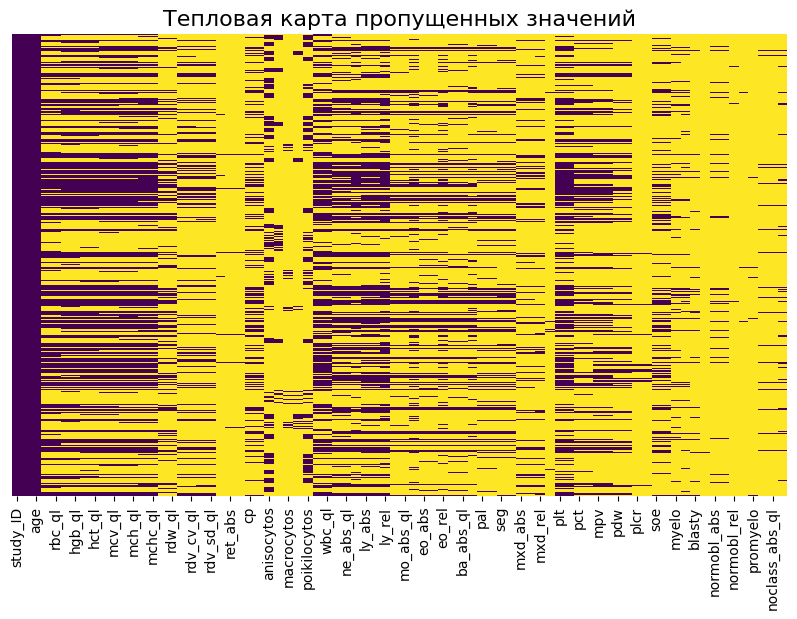

In [34]:
# Создаем тепловую карту пропусков
plt.figure(figsize=(10, 6))
sns.heatmap(work_df.isnull(), cbar=False, cmap='viridis', yticklabels=False)
plt.title('Тепловая карта пропущенных значений', fontsize=16)
plt.show()

## Синтез данных по формулам

In [ ]:
# Посчитаем значения по формуле для лейкоцитов и лейкоформуле
def rel_tocol_calc(rel_col, abs_col):
    # Условия: есть rel, есть WBC, нет abs
    cond_rel_to_abs = (
        work_df[rel_col].notna() &
        work_df['wbc'].notna() &
        work_df[abs_col].isna()
    )

    work_df.loc[cond_rel_to_abs, abs_col] = (
        work_df.loc[cond_rel_to_abs, rel_col] * work_df.loc[cond_rel_to_abs, 'wbc'] * 0.01
    )

    cond_rel_to_wbc = (
        work_df[rel_col].notna() &
        work_df['wbc'].isna() &
        work_df[abs_col].notna()    
    )

    work_df.loc[cond_rel_to_wbc, 'wbc'] = (
        work_df.loc[cond_rel_to_wbc, abs_col] / work_df.loc[cond_rel_to_wbc, rel_col] * 100
    )

    # Пары: (абсолютное, относительное)
leukocyte_pairs = [
    ('ne_abs', 'ne_rel'),
    ('ly_abs', 'ly_rel'),
    ('mo_abs', 'mo_rel'),
    ('eo_abs', 'eo_rel'),
    ('ba_abs', 'ba_rel'),
    ('mxd_abs', 'mxd_rel'),
    ('ret_abs', 'ret_rel'),
    ('noclass_abs', 'noclass_rel'),
]

# Перебор всех пар
for abs_col, rel_col in leukocyte_pairs:
    rel_tocol_calc(abs_col, rel_col)

In [ ]:
# Расчитаем значения по эритроцитам через Hct и MCV
cond_hct = (
    work_df['hct'].isna() &
    work_df['rbc'].notna() &
    work_df['mcv'].notna()
)

work_df.loc[cond_hct, 'hct'] = (
    work_df.loc[cond_hct, 'rbc'] * work_df.loc[cond_hct, 'mcv'] * 0.1
)

cond_rbc = (
    work_df['hct'].notna() &
    work_df['rbc'].isna() &
    work_df['mcv'].notna()
)

work_df.loc[cond_rbc, 'rbc'] = (
    work_df.loc[cond_rbc, 'hct'] * 10 / work_df.loc[cond_rbc, 'mcv']
)

cond_mcv = (
    work_df['hct'].notna() &
    work_df['rbc'].notna() &
    work_df['mcv'].isna()
)

work_df.loc[cond_mcv, 'mcv'] = (
    work_df.loc[cond_mcv, 'hct'] * 10 / work_df.loc[cond_mcv, 'rbc']
)

In [ ]:
# Расчитаем значения по эритроцитам через hgb и MCH
cond_hgb = (
    work_df['hgb'].isna() &
    work_df['rbc'].notna() &
    work_df['mch'].notna()
)

work_df.loc[cond_hgb, 'hgb'] = (
    work_df.loc[cond_hgb, 'rbc'] * work_df.loc[cond_hgb, 'mch'] * 0.1
)

cond_rbc = (
    work_df['hgb'].notna() &
    work_df['rbc'].isna() &
    work_df['mch'].notna()
)

work_df.loc[cond_rbc, 'rbc'] = (
    work_df.loc[cond_rbc, 'hgb'] * 10 / work_df.loc[cond_rbc, 'mch']
)

cond_mch = (
    work_df['hgb'].notna() &
    work_df['rbc'].notna() &
    work_df['mch'].isna()
)

work_df.loc[cond_mch, 'mch'] = (
    work_df.loc[cond_mch, 'hgb'] * 10 / work_df.loc[cond_mch, 'rbc']
)

In [ ]:
# Расчитаем значения по тромбоцитам где можно
cond_pct = (
    work_df['pct'].isna() &
    work_df['plt'].notna() &
    work_df['mpv'].notna()
)

work_df.loc[cond_pct, 'pct'] = (
    work_df.loc[cond_pct, 'plt'] * work_df.loc[cond_pct, 'mpv'] * 0.1
)

cond_plt = (
    work_df['pct'].notna() &
    work_df['plt'].isna() &
    work_df['mpv'].notna()
)

work_df.loc[cond_plt, 'plt'] = (
    work_df.loc[cond_plt, 'pct'] * 10 / work_df.loc[cond_plt, 'mpv']
)

cond_mpv = (
    work_df['pct'].notna() &
    work_df['plt'].notna() &
    work_df['mpv'].isna()
)

work_df.loc[cond_mpv, 'mpv'] = (
    work_df.loc[cond_mpv, 'pct'] * 10 / work_df.loc[cond_mpv, 'plt']
)

In [ ]:
# Теперь удалим отоносительные величины, так ка они расчитаны из абсолютных
list_to_drop = [
    'ne_rel', 'ly_rel', 'mo_rel', 'ret_rel', 'pct',
    'eo_rel', 'ba_rel', 'mxd_rel', 'normobl_rel',
    'mch', 'rdv_cv', 'noclass_abs_ql', 'mch_ql', 'pct_ql',
    'noclass_abs', 'noclass_rel', 'rdv_cv_ql',

]
work_df = work_df.drop(columns=list_to_drop)

В качественных показателях закодируем норму 0

In [ ]:
norm_null_list = ['plasma', 'myelo', 'yunye', 'blasty', 'normobl_abs',
                  'prolym', 'promyelo', 'normoblast',
                  'plcr', 'hypochromia', 'ret_abs', 'normobl_abs_ql',
                  'macrocytos', 'microcytos',
                  'anisocytos', 'poikilocytos',
                  ]
# Заменим пустые значения но 0 (норма там где можно)
work_df[norm_null_list] = work_df[norm_null_list].fillna(0)

Удалим все исследования где нет количества эритроцитов и лейкоцитов, их ничем не заполнить, без них нельзя интерпретировать исследование.

In [ ]:
work_df = work_df.dropna(subset=['rbc', 'wbc'], how='all')
work_df.shape

Разделим признаки на категориальные и числовые

In [ ]:
cat_list = ['study_ID', 'gender', 'plasma', 'myelo', 'yunye', 'blasty',
            'prolym', 'promyelo', 'normoblast', 'hypochromia',
            'macrocytos', 'microcytos', 'anisocytos', 'poikilocytos',]
num_list = [col for col in work_df.columns if col not in cat_list]
work_df[cat_list] = work_df[cat_list].astype('object')

In [ ]:
# Это словарь нормы, будем заполнять пустое ей, т.к. медианой или средним не правильно (ИМХО)
ref_dict = { # Словарь референсных значений
    'rbc': [3.8, 5.8],
    'hgb': [120, 140],
    'hct': [39, 49],
    'mcv': [81, 100],
    'mchc': [320, 360],
    'rdw': [11.5, 14.5],
    'rdv_sd': [37, 54],
    'ret_abs': [0.67, 1.9],
    'cp': [0.85, 1],
    'wbc': [4, 9],
    'ne_abs': [2, 5.5],
    'ly_abs': [1, 4.8],
    'mo_abs': [0.04, 0.7],
    'eo_abs': [0.02, 0.45],
    'ba_abs': [0.01, 0.05],
    'pal': [1, 5],
    'seg': [47, 72],
    'mxd_abs': [0.2, 0.8],
    'plt': [180, 320],
    'mpv': [7.4, 10.4],
    'pdw': [15, 17],
    'plcr': [13, 43],
    'soe': [2, 10],
    'ret_abs': [17, 63],
}

In [ ]:
# Заполним соответствие норме значениями из других строк
for col in ref_dict:
    work_df[col+'_ql'] = work_df[col+'_ql'].fillna(work_df.groupby(col)[col+'_ql'].transform('first'))

In [ ]:
# Создаем тепловую карту пропусков
plt.figure(figsize=(10, 6))
sns.heatmap(work_df.isnull(), cbar=False, cmap='viridis', yticklabels=False)
plt.title('Тепловая карта пропущенных значений', fontsize=16)
plt.show()

In [ ]:
import numpy as np
np.random.seed(42)

# Оставшиеся пропуски заполняем нормой
for col in ref_dict:
    mask = work_df[col].isna()
    work_df.loc[mask, col] = np.random.uniform(ref_dict[col][0], ref_dict[col][1], size=mask.sum())
    work_df[col] = work_df[col].round(2)

for col in ref_dict:
    mask = work_df[col+'_ql'].isna()
    
    def get_result(x):
        if x < ref_dict[col][0]:
            return -1
        elif x > ref_dict[col][1]:
            return 1
        else:
            return 0
    
    work_df.loc[mask, col+'_ql'] = work_df.loc[mask, col].apply(get_result)

In [ ]:
# Создаем тепловую карту пропусков
plt.figure(figsize=(10, 6))
sns.heatmap(work_df.isnull(), cbar=False, cmap='viridis', yticklabels=False)
plt.title('Тепловая карта пропущенных значений', fontsize=16)
plt.show()

In [ ]:
work_df.describe().T

In [ ]:
work_df.describe(include='object').T

In [ ]:
etalon_df = work_df.copy()

In [ ]:
etalon_df.to_csv('data/etalon_df.csv', index=False)